# Tweezer Experiment

In [ ]:
import pytweezer.phasemask as pm
import pytweezer.analysis.analysis as pyt
from pytweezer.servers.device_client import get_device
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.thorcam import ThorCam
from pytweezer.drivers.slm import SLM, SimulatedSLM
from pytweezer.arduino import ArduinoPulser
from pytweezer.coordinators.rearrangement import Rearrangement
import numpy as np
import matplotlib.pyplot as plt
import time
from rich.progress import track
from pytweezer.cpp import morph_tophat_cpp as mt

texp = pyt.TweezerExperimentAnalysis(day='10',month='06Jun', year='2026')

#### Initialise Devices

In [7]:
rb_exp = get_device("Rb MotMaster")
#thorcam: ThorCam = ThorCam()
hamcam: ImagEMX2Camera = ImagEMX2Camera()
slm = SLM(wait_for_trigger=False, output_pulse=True)
arduino = ArduinoPulser('COM5')

# ThorCam config
#thorcam.set_trigger_source("bulb")
#thorcam.set_roi(650, 600, 280, 600)

# HamCam config
hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

2026-07-28 12:14:58 | INFO     | PH-BEAST | slm | SLM board 1: 1024x1024 @ 8-bit, serial 7752, 40.169 degC
2026-07-28 12:14:58 | INFO     | PH-BEAST | slm | Loaded LUT C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT


In [23]:
arduino.connect()

'Listening for Python...'

## Generate Phasemask

In [8]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


In [9]:
gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

In [13]:
W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.30e-06 | Uniformity: 42.89% | Min/Max ratio: 0.027
Iteration 010 | Mean-Squared Error: 3.72e-08 | Uniformity: 75.49% | Min/Max ratio: 0.346
Iteration 020 | Mean-Squared Error: 4.40e-09 | Uniformity: 76.09% | Min/Max ratio: 0.379
Iteration 030 | Mean-Squared Error: 5.12e-09 | Uniformity: 75.89% | Min/Max ratio: 0.380
Iteration 040 | Mean-Squared Error: 2.01e-09 | Uniformity: 75.87% | Min/Max ratio: 0.377
Iteration 050 | Mean-Squared Error: 5.52e-10 | Uniformity: 75.94% | Min/Max ratio: 0.386
Iteration 060 | Mean-Squared Error: 4.02e-10 | Uniformity: 75.97% | Min/Max ratio: 0.385
Iteration 070 | Mean-Squared Error: 1.79e-10 | Uniformity: 75.99% | Min/Max ratio: 0.384
Iteration 080 | Mean-Squared Error: 1.50e-10 | Uniformity: 75.97% | Min/Max ratio: 0.383
Iteration 090 | Mean-Squared Error: 2.97e-10 | Uniformity: 75.99% | Min/Max ratio: 0.382
Itera

In [51]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline Scan

Output()

Text(0.5, 1.0, 'Hamamatsu Camera')

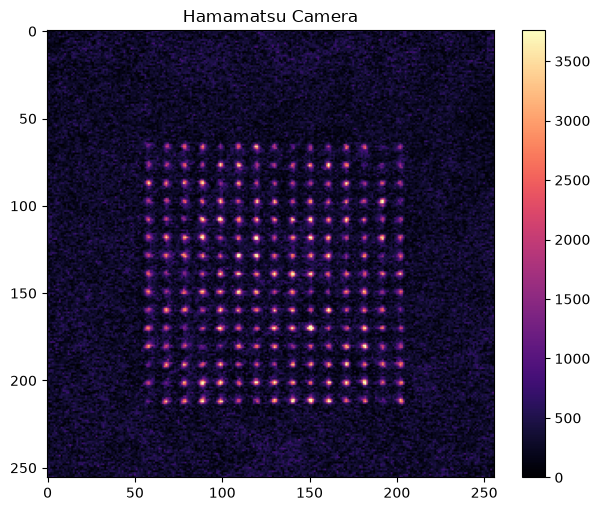

In [47]:
# Experiment and camera setup
n_iterations = 10

rb_exp.set_motmaster_experiment("RbTweezerBasic2026_2")
rb_exp.set_iterations(1)
rb_exp.set_save_toggle(False)
rb_exp.set_run_until_stopped(False)

hamcam.setup_acquisition("snap", 2)

imgs_ham, imgs_thor = [], []
for it in track(range(n_iterations)):

    hamcam.start_acquisition()

    rb_exp.start_motmaster_experiment()

    ham = hamcam.acquire_n_frames(2)

    imgs_ham.append(ham)

imgs_ham = np.array(imgs_ham)

imgs_1, imgs_2 = imgs_ham[:, 0], imgs_ham[:, 1]
imgs_ham_mean = mt.tophat(imgs_1.mean(axis=0) - imgs_2.mean(axis=0), feature_size=10)

plt.figure(figsize=(6, 5), constrained_layout=True)
plt.imshow(imgs_ham_mean, cmap="magma", vmax=imgs_ham_mean.max()*0.6)
plt.colorbar()
plt.title("Hamamatsu Camera")

Looking for trap sites...
15x15 array detected.


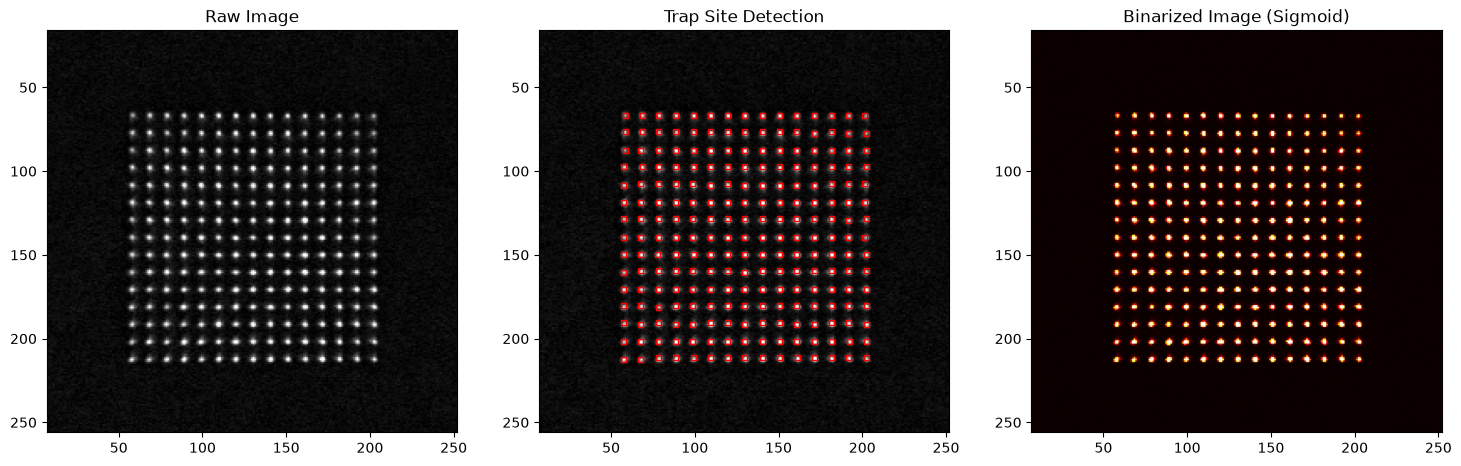

In [17]:
array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = mt.tophat(imgs_ham_mean, feature_size=feature_size)
grid_positions, detection_threshold = pyt.detect_trap_sites(filtered_img_average, array_shape, detection_step=100)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

Trap (0, 0) Loading Probability : 56.00 %
Trap (0, 1) Loading Probability : 57.00 %
Trap (0, 2) Loading Probability : 57.00 %
Trap (0, 3) Loading Probability : 52.00 %
Trap (0, 4) Loading Probability : 63.00 %
Trap (0, 5) Loading Probability : 58.00 %
Trap (0, 6) Loading Probability : 59.00 %
Trap (0, 7) Loading Probability : 56.00 %
Trap (0, 8) Loading Probability : 58.00 %
Trap (0, 9) Loading Probability : 51.00 %
Trap (0, 10) Loading Probability : 52.00 %
Trap (0, 11) Loading Probability : 53.00 %
Trap (0, 12) Loading Probability : 55.00 %
Trap (0, 13) Loading Probability : 57.00 %
Trap (0, 14) Loading Probability : 54.00 %
Trap (1, 0) Loading Probability : 55.00 %
Trap (1, 1) Loading Probability : 61.00 %
Trap (1, 2) Loading Probability : 46.00 %
Trap (1, 3) Loading Probability : 50.00 %
Trap (1, 4) Loading Probability : 51.00 %
Trap (1, 5) Loading Probability : 58.00 %
Trap (1, 6) Loading Probability : 59.00 %
Trap (1, 7) Loading Probability : 52.00 %
Trap (1, 8) Loading Probabili

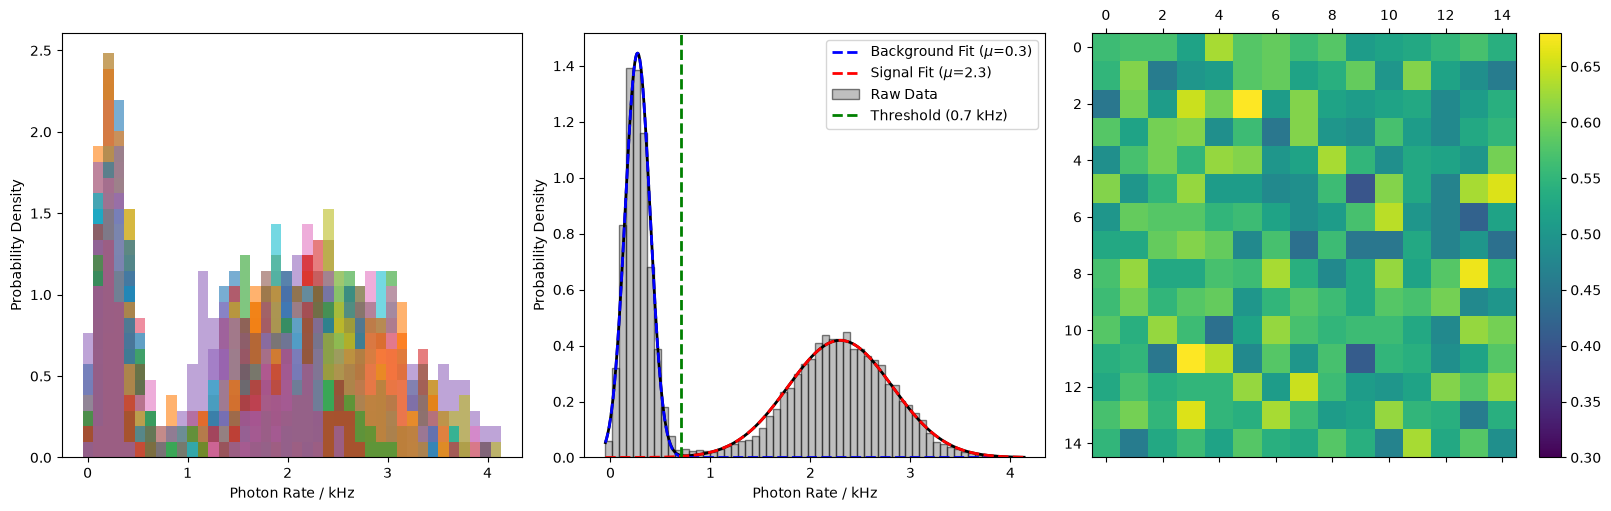

In [18]:
imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

---
## Rearrangement Testing

In [19]:
gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

In [20]:
W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()
terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.59e-06 | Uniformity: 43.57% | Min/Max ratio: 0.042
Iteration 010 | Mean-Squared Error: 2.26e-08 | Uniformity: 75.48% | Min/Max ratio: 0.357
Iteration 020 | Mean-Squared Error: 5.33e-09 | Uniformity: 76.18% | Min/Max ratio: 0.382
Iteration 030 | Mean-Squared Error: 2.45e-09 | Uniformity: 76.07% | Min/Max ratio: 0.375
Iteration 040 | Mean-Squared Error: 1.13e-09 | Uniformity: 75.99% | Min/Max ratio: 0.380
Iteration 050 | Mean-Squared Error: 9.25e-10 | Uniformity: 75.97% | Min/Max ratio: 0.377
Iteration 060 | Mean-Squared Error: 7.18e-10 | Uniformity: 76.02% | Min/Max ratio: 0.384
Iteration 070 | Mean-Squared Error: 3.39e-10 | Uniformity: 75.99% | Min/Max ratio: 0.386
Iteration 080 | Mean-Squared Error: 6.31e-10 | Uniformity: 76.04% | Min/Max ratio: 0.383
Iteration 090 | Mean-Squared Error: 4.88e-10 | Uniformity: 76.02% | Min/Max ratio: 0.382
Itera

In [21]:
W2 = np.ones((10, 10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()
terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.75e-05 | Uniformity: 51.97% | Min/Max ratio: 0.045
Iteration 010 | Mean-Squared Error: 2.78e-07 | Uniformity: 83.61% | Min/Max ratio: 0.500
Iteration 020 | Mean-Squared Error: 5.70e-08 | Uniformity: 82.71% | Min/Max ratio: 0.515
Iteration 030 | Mean-Squared Error: 1.55e-08 | Uniformity: 83.36% | Min/Max ratio: 0.518
Iteration 040 | Mean-Squared Error: 3.67e-09 | Uniformity: 83.64% | Min/Max ratio: 0.523
Iteration 050 | Mean-Squared Error: 9.11e-10 | Uniformity: 83.65% | Min/Max ratio: 0.528
Iteration 060 | Mean-Squared Error: 1.73e-09 | Uniformity: 83.75% | Min/Max ratio: 0.529
Iteration 070 | Mean-Squared Error: 9.79e-10 | Uniformity: 83.71% | Min/Max ratio: 0.530
Iteration 080 | Mean-Squared Error: 2.78e-10 | Uniformity: 83.65% | Min/Max ratio: 0.530
Iteration 090 | Mean-Squared Error: 9.01e-11 | Uniformity: 83.61% | Min/Max ratio: 0.530
Itera

---

In [22]:
site_sums = np.array([
    pyt.sum_pixel_values(pyt.morphological_tophat_high_pass(img, feature_size=10),
                        grid_positions, [15,15], window_size=3).flatten()
    for img in imgs_1
])
threshold, *_ = pyt.detect_loading_threshold(site_sums.flatten())
print(f"threshold = {threshold:.2f}")

threshold = 10017.95


In [48]:
coordinator = Rearrangement({'slm': slm}, {})
coordinator._state = {'grid_positions': grid_positions}   # enough for _extract_occupancy

GRID_SHAPE = [15,15]
terms_init = terms1
terms_final = terms2
D0 = 1.2
PROFILE = 'linear'
PULSE_PERIOD_US = 700

In [49]:
rb_exp = get_device("Rb MotMaster")
rb_exp.set_motmaster_experiment("RbTweezerBasic2026_2")
rb_exp.set_iterations(1)
rb_exp.set_save_toggle(False)
rb_exp.set_run_until_stopped(False)

In [52]:
import time
t0 = time.time()
rb_exp.start_motmaster_experiment({"BackgroundDrop": 0})
t1 = time.time()
print(f"Experiment time: {t1 - t0:.2f} s")

Experiment time: 2.43 s


In [ ]:
import threading

rb_exp.set_motmaster_experiment("RbTweezerBasic2026_2")
rb_exp.set_iterations(1)
rb_exp.set_save_toggle(False)
rb_exp.set_run_until_stopped(False)
hamcam.setup_acquisition("snap", 1)
hamcam.start_acquisition()

# start_motmaster_experiment blocks until the whole physical sequence finishes
# but the sequence needs the rearrangement done
# and the Arduino trigger fired while it's still running between its two
# camera triggers. Run it on a thread so this cell can react to the trigger
# and do the rearrangement concurrently instead of after the sequence is over.
motmaster_error = [None]

def _run_motmaster():
    try:
        rb_exp.start_motmaster_experiment({"BackgroundDrop": 0})
    except Exception as exc:
        motmaster_error[0] = exc

motmaster_thread = threading.Thread(target=_run_motmaster, daemon=True)
motmaster_thread.start()

image1 = hamcam.acquire_n_frames(1)[0]

occ_mask = coordinator._extract_occupancy(image1, GRID_SHAPE, threshold)
print(f'occupancy: {occ_mask.sum()} / {occ_mask.size} atoms loaded')

slm.set_wait_for_trigger(False)
frames = PM.iter_rearrangement_sequence(terms_init, terms_final, occ_mask,
                                        d0=D0, profile=PROFILE, to_host=False)
n = coordinator._preload_sequence_pipelined(frames)

slm.set_wait_for_trigger(True)
slm.start_auto_increment(n)
span = arduino.send_pulses(n - 1, period_us=1*PULSE_PERIOD_US)
slm.stop_auto_increment()
slm.set_wait_for_trigger(False)

period = span / max(n - 2, 1)
print(f'{n} frames delivered, move = {(n - 1) * period * 1e3:.2f} ms')

hamcam.start_acquisition()
image2 = hamcam.acquire_n_frames(1)[0]

motmaster_thread.join(timeout=30)
if motmaster_error[0] is not None:
    raise motmaster_error[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(image1, cmap='gray', vmax=image1.max()*0.6)
ax1.set_title('Image 1')
ax2.imshow(image2, cmap='gray', vmax=image2.max()*0.6)
ax2.set_title('Image 2')
plt.show()